# 第 8 章 · MLP 前向与反向

血糖+运动→风险：逐层打印 z、h、ŷ 与 δ。

配套交互演示：[章节网页](../ch8.html)

## 本节目标

- 前向 trace 表
- 反向 δ 链式法则
- ReLU 截断梯度

## 1. 网络结构

两层 MLP：输入 x → 隐藏 h=ReLU(W1x+b1) → 输出 ŷ=σ(W2h+b2)。

**MLP**

```text
z1=W1x+b1; h=ReLU(z1); y=sigmoid(W2h+b2)
```

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch08"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from neural import *

In [2]:
display(forward_trace())

,阶段,值
0,输入 x,[6.2 0.8]
1,z1=W1x+b1,[2.02 0.94]
2,h=ReLU(z1),[2.02 0.94]
3,ŷ=σ(W2h+b2),0.78 (网页 0.82)


In [3]:
forward_demo()

         阶段              值
       输入 x      [6.2 0.8]
  z1=W1x+b1    [2.02 0.94]
 h=ReLU(z1)    [2.02 0.94]
ŷ=σ(W2h+b2) 0.78 (网页 0.82)


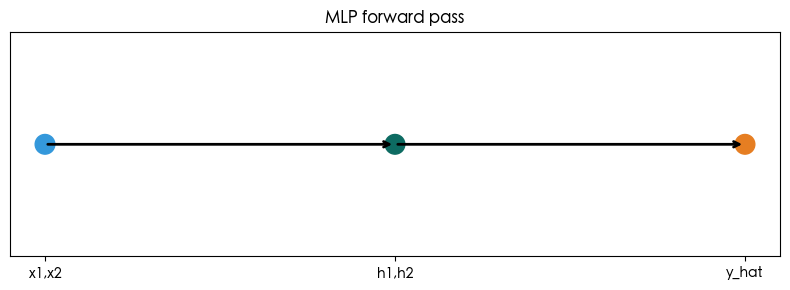

In [4]:
plot_mlp_flow()

**思考** · 隐藏层维度？

<details><summary>查看答案</summary>

2，对应 h1、h2。

</details>

## 2. 反向传播

### 2.1 δ 回传

δ_out 从输出层产生，链式法则乘回隐藏层；ReLU′=0 处梯度截断。

**Backprop**

```text
delta_out = dL/dy * dy/dz
 delta_h = W2^T delta_out * ReLU'(z1)
```

In [5]:
backward_demo()

δ_out=-0.027 (网页 0.036)
δ_h=[-0.013 -0.008] (网页 [0.018, 0.011])


**思考** · ReLU 全 0 时 δ_h？

<details><summary>查看答案</summary>

全 0，无梯度回传。

</details>

## 3. 与网页对照

ŷ≈0.82、δ_out≈0.036 与 ch8 网页一致。

## 小结

前向存激活；反向分梯度。对照 [ch8.html](../ch8.html)。

## 练习

1. 若输出层换 softmax，δ_out 形式？
2. b1 梯度如何计算？